# Hypothesis Testing: Impact of Axelrod's Tit-for-Tat on Performance

This notebook conducts statistical tests to determine whether adding Axelrod's Tit-for-Tat logic significantly alters the agent's performance, measured by Victory Points (VP).

- **Null Hypothesis ($H_0$):** There is no difference in mean VP between the base mode and the Axelrod-enhanced mode ($\mu_{no\_axelrod} = \mu_{axelrod}$).
- **Alternative Hypothesis ($H_1$):** There is a statistically significant difference ($\mu_{no\_axelrod} \neq \mu_{axelrod}$).

We use **Welch's t-test** (unequal variances t-test). It does not assume normality of the raw data because our sample sizes ($N > 2000$) satisfy the Central Limit Theorem, ensuring the sampling distribution of the mean is normal.

In [ ]:
import polars as pl
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = Path("../rl/results")
CSV_FILES = sorted(RESULTS_DIR.glob("*.csv"))

if not CSV_FILES:
    raise FileNotFoundError(f"No CSV files found in {RESULTS_DIR.resolve()}")

print(f"Found {len(CSV_FILES)} result files for analysis.")


Found 38 result files for analysis.


In [ ]:
# ── Categorize files into buckets ──────────────────────────────────────
buckets = {
    "baseline_axelrod": [],
    "baseline": [],
    "aware_axelrod": [],
    "aware": [],
    "shuffled_axelrod": [],
    "shuffled": [],
}

for f in CSV_FILES:
    name = f.stem.lower()
    if "baseline_axelrod" in name:
        buckets["baseline_axelrod"].append(f)
    elif "baseline" in name:
        buckets["baseline"].append(f)
    elif "aware_axelrod" in name:
        buckets["aware_axelrod"].append(f)
    elif "aware" in name:
        buckets["aware"].append(f)
    elif "shuffled_axelrod" in name:
        buckets["shuffled_axelrod"].append(f)
    elif "shuffled" in name:
        buckets["shuffled"].append(f)

# Load and concatenate data
dfs = {}
for label, files in buckets.items():
    if files:
        dfs[label] = pl.concat([pl.read_csv(str(f)) for f in files])
    else:
        print(f"⚠️ Warning: No data for '{label}'")

print("Data loaded successfully.")


Data loaded successfully.


## 1. Welch's t-Test: Axelrod vs. No Axelrod

We test $H_0: \mu_{base} = \mu_{axelrod}$ for each configuration.
Significance level: $\alpha = 0.05$

In [ ]:
results = []

print(f"\n{'Comparison':<30} | {'t-stat':>8} | {'p-value':>10} | {'Result':<20}")
print("-" * 80)

for mode in ["baseline", "aware", "shuffled"]:
    group_a = dfs.get(mode, None)
    group_b = dfs.get(f"{mode}_axelrod", None)
    
    if group_a is not None and group_b is not None:
        vp_a = group_a["vp"].to_numpy()
        vp_b = group_b["vp"].to_numpy()
        
        # Welch's t-test (equal_var=False)
        t_stat, p_val = stats.ttest_ind(vp_a, vp_b, equal_var=False)
        
        sig = "Significant" if p_val < 0.05 else "Not Significant"
        print(f"{mode.upper()} vs {mode.upper()}+Axelrod  | {t_stat:>8.4f} | {p_val:>10.4f} | {sig}")
        
        results.append({
            "mode": mode,
            "t_stat": t_stat,
            "p_value": p_val,
            "significant": sig,
            "mean_no_axelrod": vp_a.mean(),
            "mean_axelrod": vp_b.mean(),
            "diff": vp_a.mean() - vp_b.mean()
        })
    else:
        print(f"Skipping {mode}: missing data.")



Comparison                     |   t-stat |    p-value | Result              
--------------------------------------------------------------------------------
BASELINE vs BASELINE+Axelrod  |   1.4647 |     0.1431 | Not Significant
AWARE vs AWARE+Axelrod  |   0.5092 |     0.6107 | Not Significant
SHUFFLED vs SHUFFLED+Axelrod  |  -2.8932 |     0.0038 | Significant


## 2. Aggregated Test: All No-Axelrod vs. All Axelrod

To check if Axelrod has a *global* effect across all strategies, we pool all non-Axelrod games and all Axelrod games and run a final t-test.

In [10]:
# Pool all non-Axelrod vs all Axelrod
all_no_axelrod = pl.concat([dfs[k] for k in ["baseline", "aware", "shuffled"] if k in dfs])
all_axelrod = pl.concat([dfs[k] for k in ["baseline_axelrod", "aware_axelrod", "shuffled_axelrod"] if k in dfs])

if len(all_no_axelrod) > 0 and len(all_axelrod) > 0:
    vp_no = all_no_axelrod["vp"].to_numpy()
    vp_ax = all_axelrod["vp"].to_numpy()
    
    t_global, p_global = stats.ttest_ind(vp_no, vp_ax, equal_var=False)
    
    print("=== AGGREGATED GLOBAL TEST ===")
    print(f"N (No Axelrod): {len(vp_no):,}")
    print(f"N (Axelrod)   : {len(vp_ax):,}")
    print(f"Mean VP (No Axelrod): {vp_no.mean():.3f}")
    print(f"Mean VP (Axelrod)   : {vp_ax.mean():.3f}")
    print(f"t-stat: {t_global:.4f}")
    print(f"p-value: {p_global:.4f}")
    print(f"Result: {'Statistically Significant' if p_global < 0.05 else 'Not Statistically Significant'}")
    print("=" * 30)


=== AGGREGATED GLOBAL TEST ===
N (No Axelrod): 12,500
N (Axelrod)   : 6,500
Mean VP (No Axelrod): 7.128
Mean VP (Axelrod)   : 7.132
t-stat: -0.0753
p-value: 0.9400
Result: Not Statistically Significant


## 3. Effect Size Visualization

Even if p-values are low, we check the practical magnitude of the difference. Small VP shifts (e.g., <0.5) may be statistically significant due to large N but have negligible strategic impact.

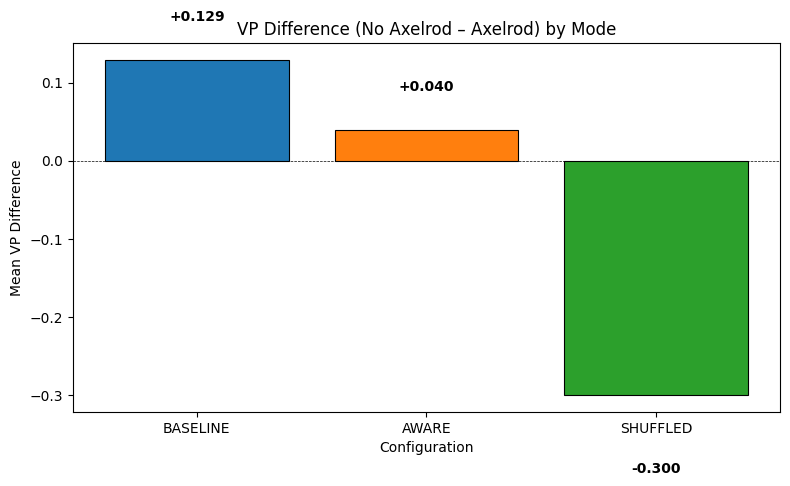

In [11]:
if results:
    fig, ax = plt.subplots(figsize=(8, 5))
    modes = [r["mode"].upper() for r in results]
    diffs = [r["diff"] for r in results]
    
    colors = ["tab:blue", "tab:orange", "tab:green"]
    ax.bar(modes, diffs, color=colors, edgecolor="black", linewidth=0.8)
    ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
    ax.set_title("VP Difference (No Axelrod – Axelrod) by Mode")
    ax.set_ylabel("Mean VP Difference")
    ax.set_xlabel("Configuration")
    
    for i, v in enumerate(diffs):
        ax.text(i, v + (0.05 if v > 0 else -0.1), f"{v:+.3f}", ha="center", fontweight="bold")
    
    plt.tight_layout()
    plt.show()
else:
    print("No results available for plotting.")


## 4. Interpretation Guidelines

- **p < 0.05**: Reject $H_0$. Axelrod statistically changes VP outcomes.
- **p > 0.05**: Fail to reject $H_0$. Observed VP differences are likely due to random variance.
- **Effect Size**: Check the mean difference. A difference of <0.1 VP may be statistically significant due to large N but practically irrelevant for actual Catan strategy.